<a href="https://colab.research.google.com/github/gracyntaxx/SmartSales/blob/main/Final_ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


# loading cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/AML_dataset/Cleaned_amazon_smartphones.csv")

# to drop duplicate items from dataset
df = df.drop_duplicates(subset=["product_name"])

# To remove invalid ratings
df =df[df["rating"] > 0]

# creating demand category
df["demand"] = df["rating_count"].apply(
    lambda x: 1 if x > 10000 else 0
)

print(df.shape)

# selecting input and output columns
X = df[["discounted_price", "actual_price", "discount_percentage", "rating"]]

y = df["demand"]

print("\nFeatures Selected")

(70, 18)

Features Selected


###Splitting dataset into training and testing

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 56
Testing Data: 14


In [31]:
print("\n----- Random Forest Classifier -----")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# training model
rf.fit(X_train, y_train)

print("Classifier Trained")

# predictions
rf_pred = rf.predict(X_test)


----- Random Forest Classifier -----
Classifier Trained


In [32]:
accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("\nAccuracy:", accuracy)


Accuracy: 0.8571428571428571


In [33]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 2  0]
 [ 2 10]]


In [34]:
# probability scores

rf_probs = rf.predict_proba(X_test)[:, 1]

# roc values

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

# auc score

auc_score = roc_auc_score(
    y_test,
    rf_probs
)

print("\nAUC Score:", auc_score)


AUC Score: 1.0


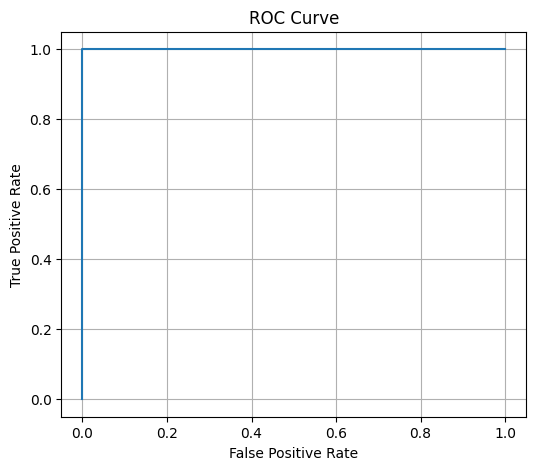

In [35]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.grid(True)

plt.show()

###Feature Importance

In [36]:
importance = rf.feature_importances_

feature_data = pd.DataFrame({"Feature": X.columns,"Importance": importance})

feature_data = feature_data.sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_data)


Feature Importance:
               Feature  Importance
2  discount_percentage    0.299130
1         actual_price    0.261386
3               rating    0.224699
0     discounted_price    0.214785


###Actual vs Predicted Graph

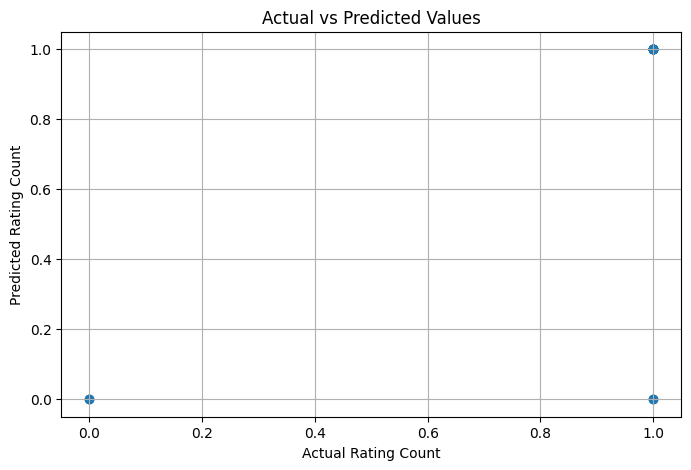

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Rating Count")
plt.ylabel("Predicted Rating Count")

plt.title("Actual vs Predicted Values")

plt.grid(True)

plt.show()

###K-Means Clustering

In [38]:
print("\n----- K-Means Clustering -----")

# selecting columns for clustering
cluster_data = df[["discounted_price", "rating"]]

# creating kmeans model
kmeans = KMeans(n_clusters=3, random_state=42)

# fitting model
df["Cluster"] = kmeans.fit_predict(cluster_data)

print("Clusters Added Successfully")


----- K-Means Clustering -----
Clusters Added Successfully


###Naming Clusters

In [39]:
cluster_names = {0: "Budget", 1: "Mid-Range", 2: "Premium"}

df["Category"] = df["Cluster"].map(cluster_names)

print("\nPhone Categories:")
print(df[["product_name", "discounted_price", "rating", "Category"]].head())


Phone Categories:
                                        product_name  discounted_price  \
1  OnePlus Nord 2T 5G (Jade Fog, 8GB RAM, 128GB S...             28999   
2  OnePlus Nord 2T 5G (Gray Shadow, 8GB RAM, 128G...             28999   
3  Redmi A1 (Black, 2GB RAM, 32GB Storage) | Segm...              6499   
4  Redmi A1 (Light Green, 2GB RAM 32GB ROM) | Seg...              6499   
5  Nokia 105 Single SIM, Keypad Mobile Phone with...              1299   

   rating Category  
1     4.3  Premium  
2     4.3  Premium  
3     4.0   Budget  
4     4.0   Budget  
5     4.0   Budget  


###Cluster Graph

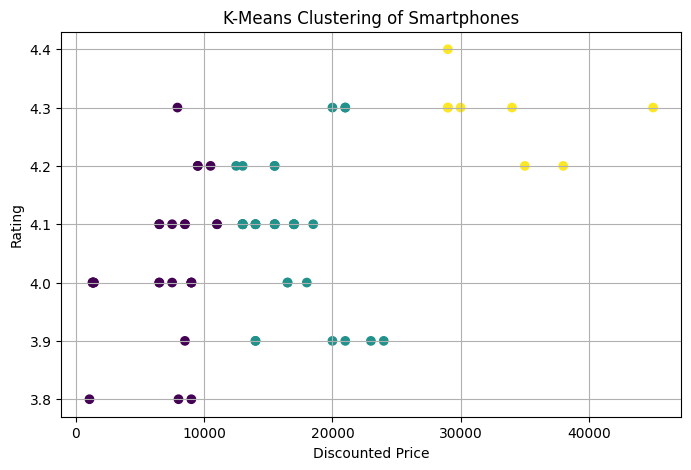

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(df["discounted_price"],df["rating"],c=df["Cluster"])

plt.xlabel("Discounted Price")
plt.ylabel("Rating")

plt.title("K-Means Clustering of Smartphones")

plt.grid(True)

plt.show()

###Saving Prediction File

In [41]:
result = pd.DataFrame({"Actual": y_test, "Predicted": rf_pred})

result.to_csv("predictions.csv", index=False)

print("\nPrediction file saved")

# Saving Cluster Dataset
df.to_csv("clustered_phones.csv", index=False)

print("Clustered dataset saved")


Prediction file saved
Clustered dataset saved


In [42]:
# Phone Prediction
print("\n----- Phone demand Prediction -----")

brand = input("Enter Phone Brand: ")

price = float(input("Enter Discounted Price: "))

actual_price = float(input("Enter Actual Price: "))

discount = float(input("Enter Discount Percentage: "))

rating = float(input("Enter Current Product Rating: "))

# creating new data for prediction

new_phone = pd.DataFrame({
    "discounted_price": [price],
    "actual_price": [actual_price],
    "discount_percentage": [discount],
    "rating": [rating]
})

# predicting demand

predicted_demand = rf.predict(new_phone)

print("\n===== Prediction Result =====")

print("Brand:", brand)

if predicted_demand[0] == 1:
    print("Predicted Demand: High Demand")

else:
    print("Predicted Demand: Low Demand")

# market category based on price

if price < 15000:
    category = "Budget Phone"

elif price < 30000:
    category = "Mid-Range Phone"

else:
    category = "Premium Phone"

print("Market Category:", category)


----- Phone demand Prediction -----
Enter Phone Brand: Samsung Galaxy s25
Enter Discounted Price: 130999
Enter Actual Price: 139999
Enter Discount Percentage: 6
Enter Current Product Rating: 4.5

===== Prediction Result =====
Brand: Samsung Galaxy s25
Predicted Demand: Low Demand
Market Category: Premium Phone
